In [1]:
import sys
sys.path.insert(0, str("/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro"))

In [2]:
import os
import numpy as np
import h5py
from tqdm import tqdm
import pandas as pd
from pathlib import Path, PurePath
from Bio import SeqIO

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import sinabro_v2 as snbr

/home/ceel/miniconda3/envs/seta_demo/lib/python3.9/site-packages/Bio/codonalign/__init__.py:23: BiopythonExperimentalWarning: Bio.codonalign is an experimental module which may undergo significant changes prior to its future official release.
  warnings.warn(


In [3]:
import h5py

def tree_h5(file_path, max_depth=3):
    """
    Print HDF5 file structure in a tree-like format.
    
    Parameters:
    - file_path: path to the HDF5 file
    - max_depth: maximum depth to traverse (default: 3)
    """
    def recurse(name, obj, prefix='', depth=1, last=False):
        # choose branch connector
        connector = '└── ' if last else '├── '
        print(prefix + connector + name)
        
        # if this is a group and we haven't reached max depth, recurse into children
        if isinstance(obj, h5py.Group) and depth < max_depth:
            children = list(obj.items())
            for i, (child_name, child_obj) in enumerate(children):
                is_last = (i == len(children) - 1)
                # extend prefix: if this was the last child, add spaces; otherwise add vertical bar
                new_prefix = prefix + ('    ' if last else '│   ')
                recurse(child_name, child_obj, new_prefix, depth + 1, is_last)

    # open file and start recursion
    with h5py.File(file_path, 'r') as f:
        print(file_path)
        root_items = list(f.items())
        for i, (name, obj) in enumerate(root_items):
            is_last = (i == len(root_items) - 1)
            recurse(name, obj, prefix='', depth=1, last=is_last)


In [5]:
tree_h5("/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/lrho_sbs2.h5")

/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/lrho_sbs2.h5
└── lrho


In [4]:
filename = "/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/lrho_sbs2.h5"
with h5py.File(filename, 'r') as f:
    print(f["/lrho"][:])
    lrhos = f["/lrho"][:]

[4.056 4.554 5.712 ... 2.771 3.274 2.56 ]


In [5]:
data_path = '/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/'
genes_fasta_file = Path(PurePath(data_path, "gencode.v40.pc_transcripts.nopary.cdsplus.longest.fa"))

seq_records = list(SeqIO.parse(genes_fasta_file, "fasta"))

In [6]:
transcript_names = []
for seq_record in seq_records:
    transcript_name = seq_record.id.split("|")[4]
    transcript_names.append(transcript_name)
    

In [14]:
len(lrhos)

3740

In [7]:
rums_nonsyn_file = Path(PurePath(data_path, "all_gencode_rums_profile.csv")) 
rums_nonsyn = pd.read_csv(rums_nonsyn_file, header=0)

rums_nonsyn

,Transcript,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,SBS7b,SBS7c,...,SBS86,SBS87,SBS88,SBS89,SBS90,SBS91,SBS92,SBS93,SBS94,SBS95
0,A1BG-201,0.578,1.176,0.358,0.390,0.467,0.653,0.663,0.615,0.253,...,0.293,0.510,0.229,0.391,0.135,0.576,0.512,0.302,0.419,0.403
1,A1CF-201,0.381,0.504,0.311,0.305,0.383,0.341,0.423,0.478,0.225,...,0.191,0.301,0.215,0.341,0.209,0.324,0.397,0.271,0.327,0.278
2,A1CF-202,0.388,0.515,0.324,0.293,0.370,0.352,0.375,0.432,0.232,...,0.171,0.285,0.218,0.309,0.221,0.318,0.411,0.291,0.321,0.279
3,A1CF-203,0.313,0.537,0.288,0.312,0.357,0.332,0.377,0.378,0.221,...,0.147,0.318,0.201,0.305,0.232,0.341,0.389,0.289,0.314,0.263
4,A1CF-204,0.340,0.510,0.286,0.283,0.356,0.317,0.380,0.402,0.217,...,0.179,0.325,0.197,0.326,0.208,0.285,0.383,0.269,0.310,0.272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73209,ZYX-201,0.640,0.778,0.331,0.350,0.344,0.559,0.488,0.530,0.256,...,0.220,0.437,0.254,0.314,0.200,0.330,0.457,0.335,0.394,0.308
73210,ZYX-203,0.529,0.825,0.346,0.315,0.401,0.514,0.571,0.651,0.246,...,0.215,0.367,0.231,0.365,0.198,0.327,0.474,0.265,0.411,0.306
73211,ZZEF1-201,0.519,0.748,0.333,0.338,0.377,0.522,0.563,0.609,0.223,...,0.216,0.371,0.239,0.331,0.188,0.383,0.417,0.283,0.381,0.290
73212,ZZZ3-201,0.207,0.288,0.237,0.196,0.370,0.431,0.255,0.312,0.148,...,0.091,0.268,0.306,0.275,0.175,0.148,0.369,0.229,0.280,0.168


In [9]:
sbs2_lrho_ns = rums_nonsyn['SBS2'].values

In [18]:
sbs2_lrho_ns = rums_nonsyn.set_index('Transcript').loc[transcript_names[:len(lrhos)], 'SBS2'].to_numpy()

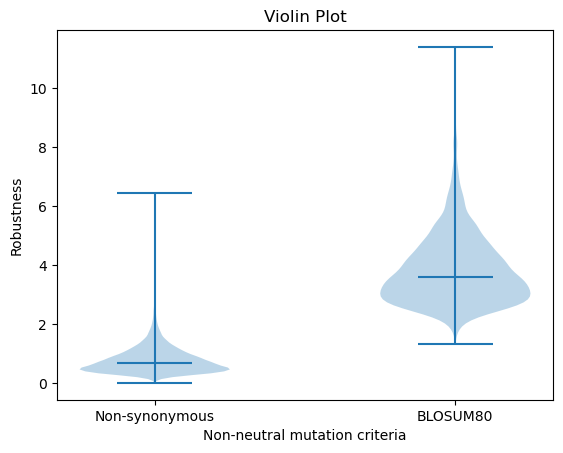

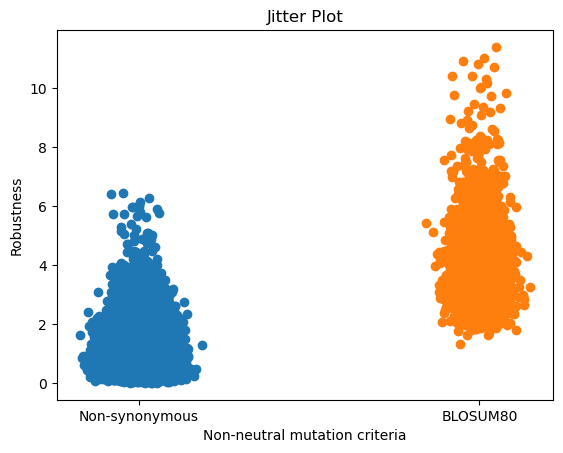

In [10]:
# Pack into list for plotting
data = [sbs2_lrho_ns, lrhos]
labels = ['Non-synonymous', 'BLOSUM80']  # x축 레이블

# ---- Violin Plot ----
plt.figure()
plt.violinplot(data, showmeans=False, showmedians=True)
plt.xticks([1, 2], labels)
plt.xlabel('Non-neutral mutation criteria')
plt.ylabel('Robustness')
plt.title('Violin Plot')
plt.show()

# ---- Jitter Plot ----
plt.figure()
# Generate x-coordinates with jitter around 1 and 2
x1 = np.random.normal(1, 0.04, size=len(sbs2_lrho_ns))
x2 = np.random.normal(2, 0.04, size=len(lrhos))

plt.scatter(x1, sbs2_lrho_ns)
plt.scatter(x2, lrhos)
plt.xticks([1, 2], labels)
plt.xlabel('Non-neutral mutation criteria')
plt.ylabel('Robustness')
plt.title('Jitter Plot')
plt.show()

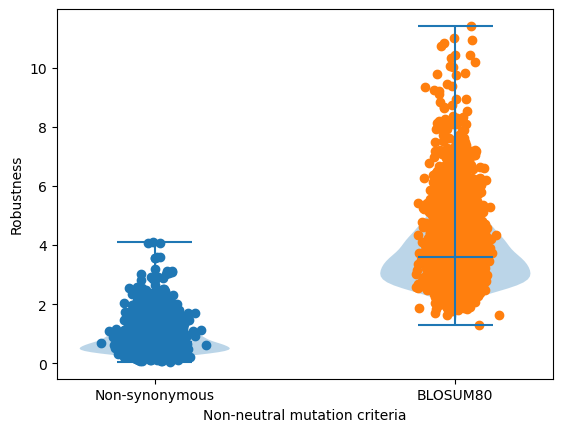

In [23]:
# 하나의 figure와 axis 생성
fig, ax = plt.subplots()

# ---- Violin Plot ----
# positions로 각각 x=1, x=2에 배치
ax.violinplot(data, positions=[1, 2], showmeans=False, showmedians=True)

# ---- Jitter Scatter ----
# 각 그룹 위치에 약간의 랜덤 노이즈를 주어 흩뿌리기
x1 = np.random.normal(1, 0.04, size=len(sbs2_lrho_ns))
x2 = np.random.normal(2, 0.04, size=len(lrhos))
ax.scatter(x1, sbs2_lrho_ns)
ax.scatter(x2, lrhos)

# 축 레이블 및 틱 설정, 타이틀 생략
ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_xlabel('Non-neutral mutation criteria')
ax.set_ylabel('Robustness')

plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

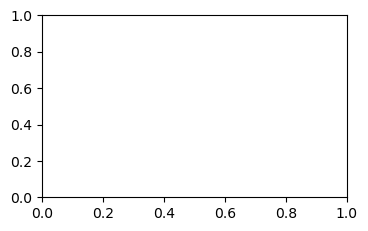

In [12]:
# Helper: cm → inch 변환 (1 inch = 2.54 cm)
def cm2inch(x):
    return x / 2.54

# 원하는 크기 (cm 단위)
width_cm, height_cm = 10, 6  # 예: 가로 10cm, 세로 6cm

# figsize에 인치 단위로 변환하여 전달
fig, ax = plt.subplots(figsize=(cm2inch(width_cm), cm2inch(height_cm)))

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

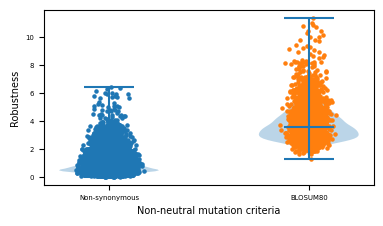

In [13]:
# 1) 전역 폰트를 Arial로 설정
plt.rc('font', family='Arial')

# 2) Figure 크기 지정 (inch 단위)
fig, ax = plt.subplots(figsize=(cm2inch(width_cm), cm2inch(height_cm)))

# 3) Violin plot
data = [sbs2_lrho_ns, lrhos]
positions = [1, 2]
ax.violinplot(data, positions=positions, showmeans=False, showmedians=True)

# 4) Jitter scatter (점 크기 s=10)
x1 = np.random.normal(positions[0], 0.04, size=len(sbs2_lrho_ns))
x2 = np.random.normal(positions[1], 0.04, size=len(lrhos))
ax.scatter(x1, sbs2_lrho_ns, s=5)
ax.scatter(x2, lrhos,         s=5)

# 5) 축 레이블 및 틱 폰트 사이즈
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=5)
ax.set_xlabel('Non-neutral mutation criteria', fontsize=7)
ax.set_ylabel('Robustness',                       fontsize=7)
ax.tick_params(axis='both', which='major', labelsize=5)

plt.tight_layout()

# 6) 파일로 저장
fig.savefig('/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/sbs2_partial.png', dpi=600)
fig.savefig('/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/sbs2_partial.svg')

plt.show()

In [14]:
import matplotlib.font_manager as fm

# ttf 리스트 중 이름에 'Arial' 이 포함된 폰트를 모두 뽑아 봅니다.
arial_list = [f for f in fm.fontManager.ttflist if 'arial' in f.name.lower()]

if arial_list:
    print("Found Arial fonts:")
    for f in arial_list:
        print(f"  - {f.name}  ({f.fname})")
else:
    print("Arial not found on this system.")

Arial not found on this system.
